# Étape 06 — calcul du BKT extrapolé

C'est ici que le chiffre FINAL du BKT est produit : à partir du BKT observé (étape 05, qui ne couvre
que les communes instrumentées), extrapole aux communes sans capteur - voir `bkt_extrapole.py` pour la
formule (« rognage Z »).

## 0. Configuration — [`pipeline.py`](pipeline.py)

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
pd.set_option("display.width", 160)

DOSSIER_BKT = RACINE / "data" / "donnees_valides" / "bkt"

## 1. Résultat déjà préparé (ou à préparer) — [`pipeline.py`](pipeline.py)

In [2]:
if not (DOSSIER_BKT / "bkt_final_national.csv").exists():
    print("Pas encore calculé - lancement de pipeline.py.")
    import runpy
    runpy.run_path(str(ICI / "pipeline.py"), run_name="__main__")
else:
    print(f"déjà calculé : {DOSSIER_BKT}")

déjà calculé : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\bkt


## 2. La formule — [`bkt_extrapole.py`](bkt_extrapole.py)

    BKT_ext(cluster) = BKT_obs(cluster) + taux_fréquentation(cluster) x L_non_obs(cluster)

**« Z complet »** (un (commune, cluster) ne compte "observé" une année QUE si il a produit du signal
cette année-là) et un **taux ROGNÉ** par cluster (moyenne du taux bike-km/km de CHAQUE commune
active du cluster, valeurs extrêmes retirées). L_obs et L_total utilisent le linéaire déjà réparti par
cluster (étape 05, voir 'linéaire(commune, cluster)') - une commune multi-clusters contribue à
plusieurs clusters à la fois, chacun avec sa part.

In [3]:
detail = pd.read_csv(DOSSIER_BKT / "bkt_final_detail_par_cluster.csv")
detail[detail["annee"] == 2025][["cluster_nom", "n_communes_actives", "l_obs", "l_total", "taux_fréquentation", "bkt_obs", "bkt_ext"]].round(3)

,cluster_nom,n_communes_actives,l_obs,l_total,taux_fréquentation,bkt_obs,bkt_ext
24,Péri-urbain loisirs,95,4484.143,25477.332,81190.622,8.741363e+08,2.578586e+09
25,Domicile travail,124,13459.474,27949.518,131547.580,4.702460e+09,6.608590e+09
26,Tourisme aménagé,342,7663.698,47198.551,38506.673,7.070215e+08,2.229377e+09
27,Tourisme rural,268,5492.991,33968.732,26020.621,2.875344e+08,1.028491e+09


## 3. Le chiffre final : BKT national, par année

In [4]:
import matplotlib.pyplot as plt

national = pd.read_csv(DOSSIER_BKT / "bkt_final_national.csv")
national

,annee,bkt_obs_Mdkm,bkt_ext_Mdkm
0,2019,2.385946,6.143231
1,2020,3.385852,7.475249
2,2021,4.944310,9.717234
3,2022,5.400607,10.929124
4,2023,5.971576,11.152994
5,2024,6.302659,11.314373
6,2025,6.571152,12.445045


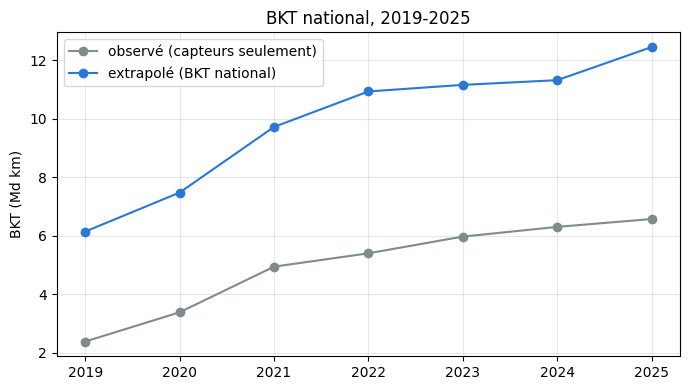

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(national["annee"], national["bkt_obs_Mdkm"], marker="o", label="observé (capteurs seulement)", color="#7f8c8d")
ax.plot(national["annee"], national["bkt_ext_Mdkm"], marker="o", label="extrapolé (BKT national)", color="#2a78d6")
ax.set_ylabel("BKT (Md km)")
ax.set_title("BKT national, 2019-2025")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Vérification de cohérence

Contrôle interne : `bkt_ext_Mdkm` doit toujours être supérieur ou égal à `bkt_obs_Mdkm` (l'extrapolation
ajoute du linéaire non observé, elle n'en retire jamais), et la part extrapolée doit rester dans un
intervalle plausible (le BKT observé, mesuré sur une minorité de communes instrumentées, ne peut pas
représenter la quasi-totalité du BKT national).

In [6]:
national["pct_extrapole"] = (1 - national["bkt_obs_Mdkm"] / national["bkt_ext_Mdkm"]) * 100
print(national.round(3))
assert (national["bkt_ext_Mdkm"] >= national["bkt_obs_Mdkm"]).all(), "bkt_ext < bkt_obs quelque part - incohérence"
assert national["pct_extrapole"].between(30, 90).all(), "part extrapolée hors d'une fourchette plausible"
print("\nOK : bkt_ext >= bkt_obs partout, part extrapolée plausible (30-90%).")

   annee  bkt_obs_Mdkm  bkt_ext_Mdkm  pct_extrapole
0   2019         2.386         6.143         61.161
1   2020         3.386         7.475         54.706
2   2021         4.944         9.717         49.118
3   2022         5.401        10.929         50.585
4   2023         5.972        11.153         46.458
5   2024         6.303        11.314         44.295
6   2025         6.571        12.445         47.199

OK : bkt_ext >= bkt_obs partout, part extrapolée plausible (30-90%).


## Bilan

Le chiffre final du BKT (`bkt_final_national.csv`, colonne `bkt_ext_Mdkm`) passe les contrôles de
cohérence interne : toujours au moins égal au BKT observé, part extrapolée dans une fourchette
plausible compte tenu de la faible proportion de communes instrumentées.